In [3]:
import torch
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import sys
import numpy as np
import scipy
from scipy import stats
import pandas as pd
import scanpy
import anndata
import power_spherical
import hyperspherical_vae

# --- IMPORT FUNCTIONS FOR TRAINING, OBJECTIVE EVALUATION ETC. ---
import importlib


In [4]:
# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rc
rc_params = {
	"font.family": "sans-serif", # "text.usetex": True,
	"font.serif" : ['Arial'], # "font.size" : 6,
	"font.weight" : "normal",
	'xtick.labelsize' : 5,
	'ytick.labelsize' : 5,
	'legend.fontsize' : 5,
	'axes.labelsize' : 6,
	'axes.linewidth': 0.8,
	'lines.linewidth' : 1
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
	"left"   :     0.2,
	'right' : 1.0,
	'bottom' : 0.15
}

In [113]:

# --- INIT ---



# which data to use
head_folder = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint'
hvg_to_use = 'connected'
cluster_resolution = 0.1

# get corresponding paths
hvg_folder = '%s/data_annotations/hvg/%s' % (head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)
reg_head_folder = '%s/bayesian_harmonic_reg' % clustering_folder

# set the core clock genes of interest
clock_genes = ['Arntl','Clock','Dbp',"Nr1d1"]


# adata path
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder


In [114]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [115]:
# --- ADD CLUSTERS TO ADATA ---



# ** load clusters **
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(cluster_df.index)]

# ** add clusters **
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


Trying to set attribute `.obs` of view, copying.


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [116]:
# --- ADD DESCRIPTION COLUMN ---

def get_description(row):
    sex = row['sex']
    misaligned = row['misaligned']
    misaligned = 'misaligned' if misaligned else "aligned"
    # zt = row['zt']
    bmal1_ko = row['bmal1_ko']
    bmal1_ko = 'bmal1-ko' if bmal1_ko else "bmal1-control"
    description = "%s %s %s" % (sex, misaligned, bmal1_ko)
    return description

print("Labeling description")
adata.obs['description'] = adata.obs.apply(lambda row: get_description(row), axis=1)





Labeling description


In [117]:
# --- LIMIT TO CLOCK GENES ---

adata = adata[:,clock_genes]


adata

View of AnnData object with n_obs × n_vars = 145271 × 4
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [123]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

descriptions = list(adata.obs['description'].unique())
# ** get rid of misaligned **
descriptions = list(filter (lambda x: "misaligned" not in x, descriptions))
clusters = sorted(list(adata.obs['cluster'].unique()))
times = sorted(list(adata.obs['zt'].unique()))
print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)
print("Unique times:\n",times)





Unique descriptions:
 ['male aligned bmal1-ko', 'female aligned bmal1-ko', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3, 4, 5, 6, 7]
Unique times:
 [0, 6, 12, 18]


In [124]:
# --- MAKE SURE MINIMUM NUMBER OF CELLS AT EACH TIME POINT / CONDITION FOR EACH CLUSTER ---


# ** get use_cluster_vec **
min_cell_count = 30
ignore_cluster_vec = np.zeros((len(clusters)))
for cluster_index,cluster in enumerate(clusters):
    ignore_cluster = False
    for condition in descriptions:
            for time_index,time in enumerate(times):
                bool_val = (adata.obs['description'] == condition) & (adata.obs['zt'] == time) & (adata.obs['cluster'] == cluster)
                adata_subset = adata[bool_val]
                if adata_subset.shape[0] < min_cell_count:
                    ignore_cluster = True
                    break
    ignore_cluster_vec[cluster_index] = ignore_cluster
use_cluster_vec = (1 - ignore_cluster_vec).astype(bool)

# ** subset clusters to only these **
clusters = list(np.array(clusters)[use_cluster_vec])



In [120]:
# --- MAKE THE CLUSTER INDEX - NAME MAP ---


cluster_index_name_map = {
    0: "SMC",
    1 : "Fibroblast",
    2 : "Endothelial",
    3 : "Macrophage",
    4 : "Unknown 1",
    5 : "Unknown 2",
    6 : "Unknown 3",
    7 : "Unknown 4"
}




In [137]:
# --- FOR EACH CLUSTER GET IT'S PROP'S OVER TIME ---
import warnings
warnings.filterwarnings('ignore')

num_samples_per_cell = 100
condition_cluster_time_prop_ecdf_list = []

# init condition_cluster_time_prop_ecdf: [num_conditions, num_clusters x num_times x num_genes x 101]
condition_cluster_time_prop_ecdf = np.zeros((len(descriptions), len(clusters), len(times), adata.shape[1], 101))


for condition_index, condition in enumerate(descriptions):
    
    print("Condition: %s" % condition)
    
    # fill condition_cluster_time_prop_ecdf
    for cluster_index,cluster in enumerate(clusters):
        
        # get the cluster condition adata
        cluster_condition_adata = adata[(adata.obs['description'] == condition) & (adata.obs['cluster'] == cluster_index)]
    
        for time_index,time in enumerate(times):


            # get cluster condition time adata
            cluster_condition_time_adata = cluster_condition_adata[cluster_condition_adata.obs['zt'] == time]

            # sample proportions: [num_samples x num_cells x num_genes]
            alpha = torch.Tensor(np.array(1 + cluster_condition_time_adata.X.todense()))
            beta = torch.Tensor(np.array([1]))
            dist = torch.distributions.gamma.Gamma(alpha,beta)
            samples = dist.sample((num_samples_per_cell,))
            samples = samples / torch.Tensor(np.array(cluster_condition_time_adata.obs['lib_size'])).unsqueeze(0).unsqueeze(2)

            # flatten sample proportions across cells: [(num_samples * num_cells) x num_genes]
            samples = torch.flatten(samples, start_dim=0, end_dim=1)

            # get the percentiles: [101 x num_genes]
            condition_cluster_time_prop_ecdf[condition_index,cluster_index,time_index,:,:] = torch.quantile(samples,quantiles,dim=0).detach().numpy().T






Condition: male aligned bmal1-ko
Condition: female aligned bmal1-ko
Condition: male aligned bmal1-control
Condition: female aligned bmal1-control


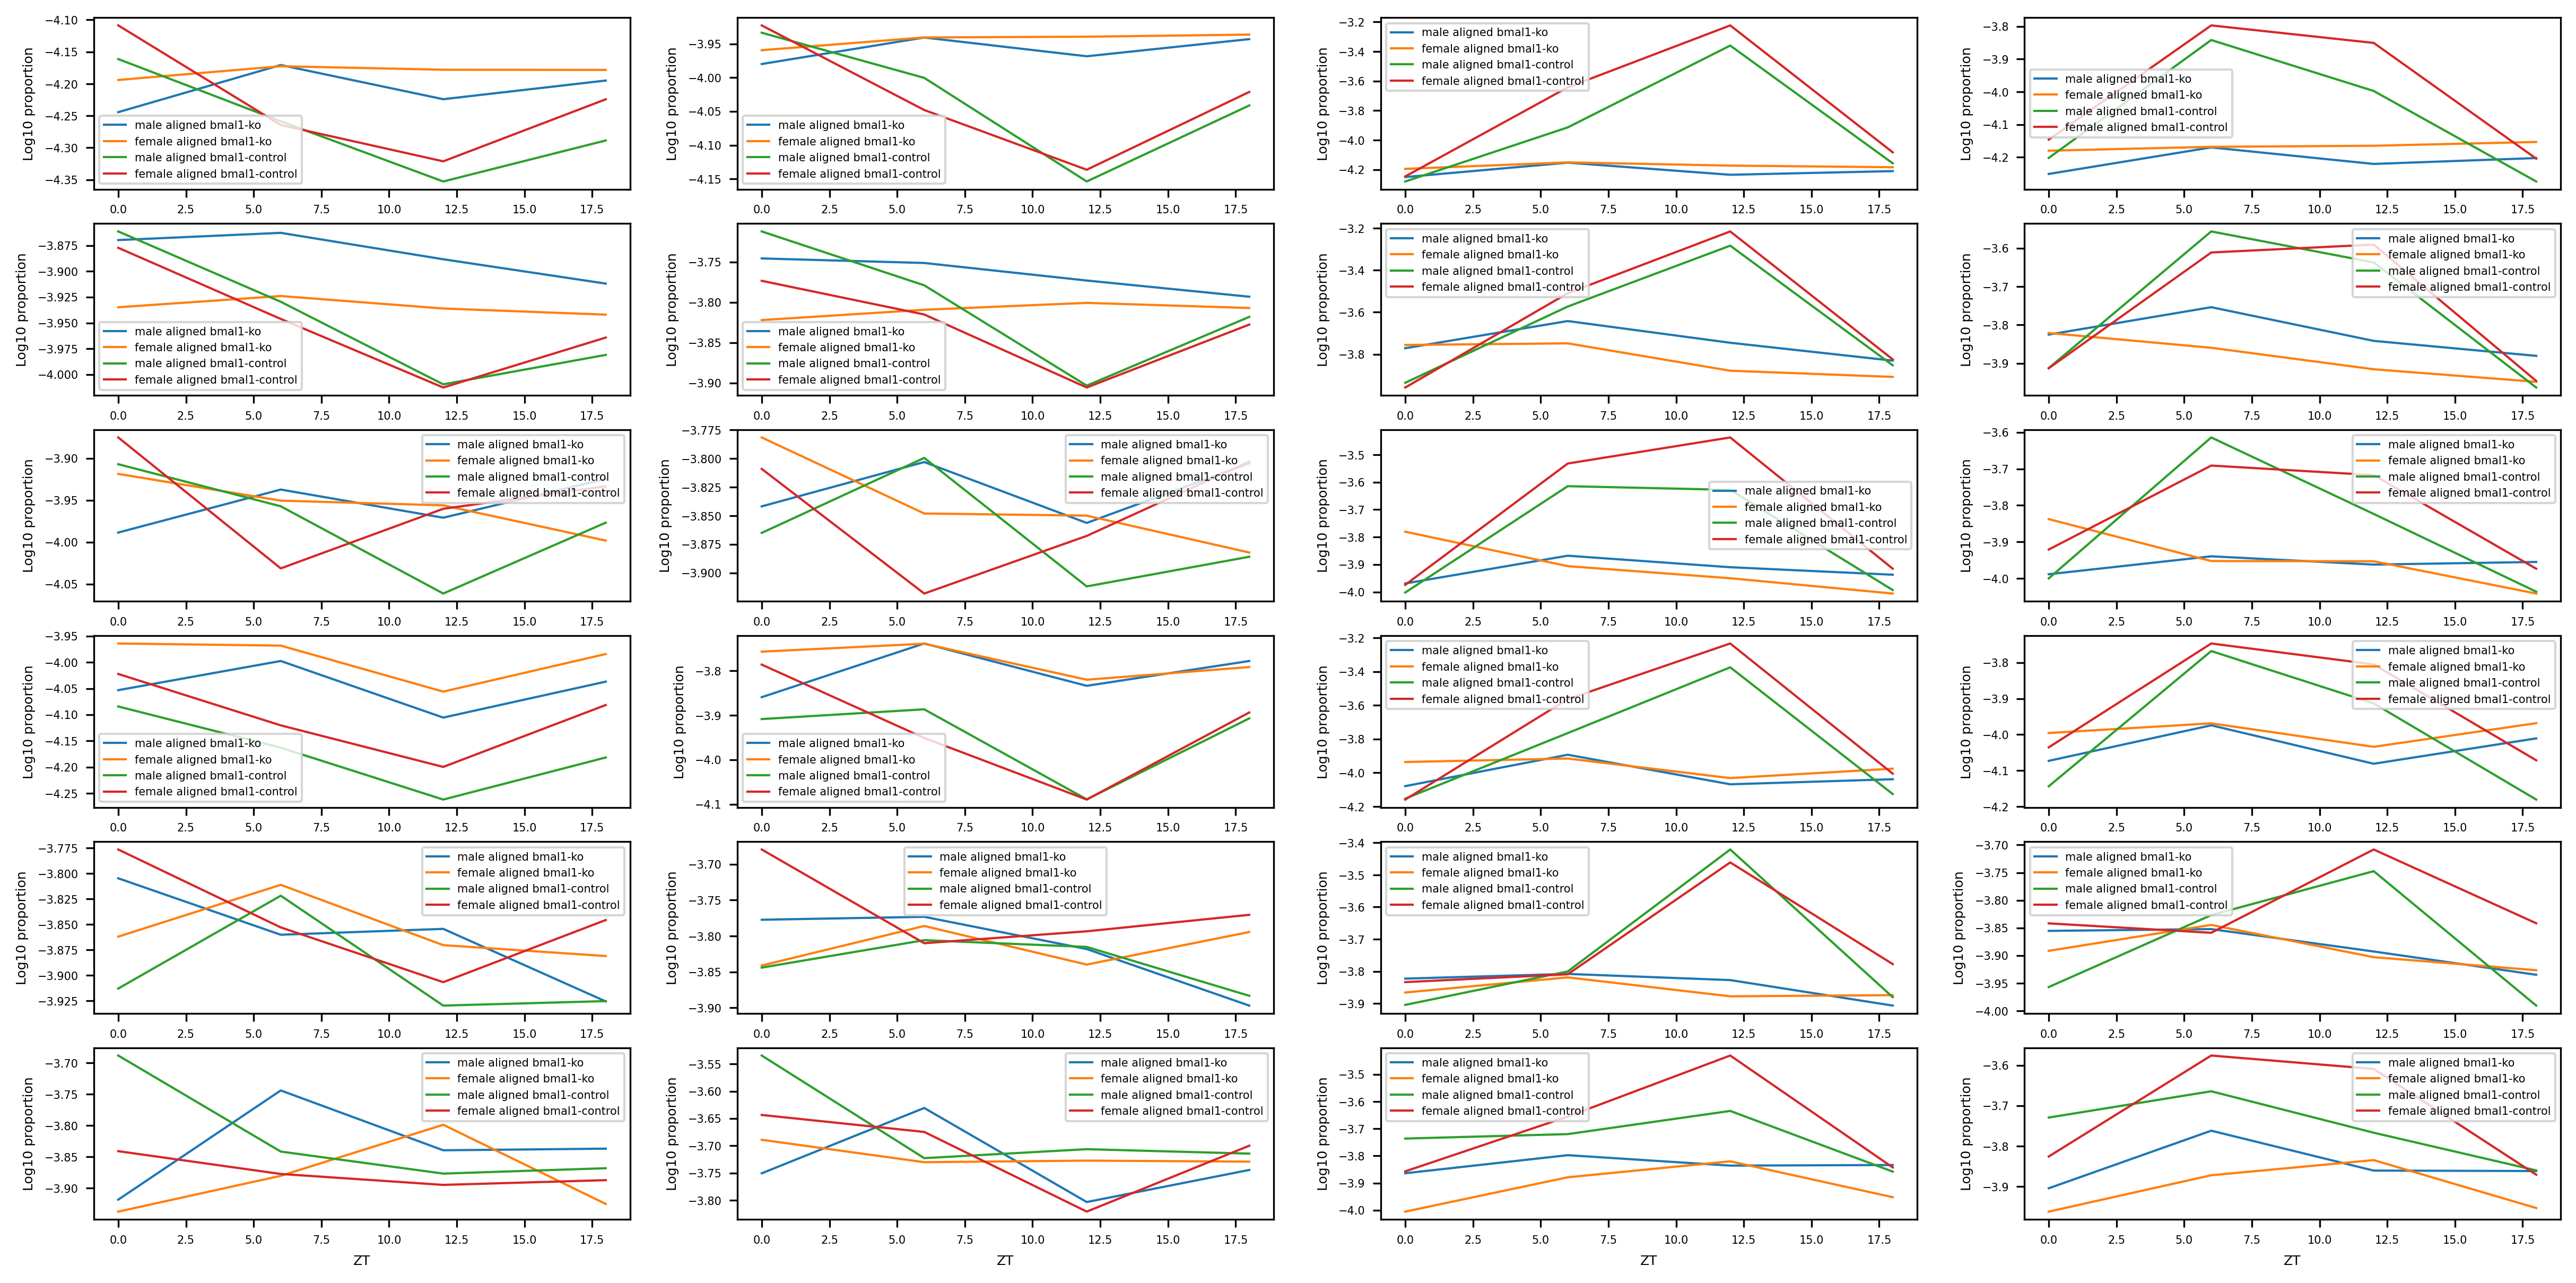

In [138]:
fig, axs = plt.subplots(len(clusters), adata.shape[1], figsize = (20,10),dpi=300)


for gene_index, gene in enumerate(adata.var_names):
    
    for cluster_index,cluster in enumerate(clusters):
    
        ax = axs[cluster_index,gene_index]
        
        for condition_index, condition in enumerate(descriptions):



            percentile = 50
            ## combine these different collections into a list
            data_to_plot = [log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,0,gene_index,percentile],
                           log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,1,gene_index,percentile],
                           log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,2,gene_index,percentile],
                           log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,3,gene_index,percentile]]



            ax.plot([0,6,12,18],data_to_plot,label=descriptions[condition_index])
        ax.legend()
        ax.set_ylabel("Log10 proportion")
        ax.set_xlabel("ZT")







(-6.0, -2.0)

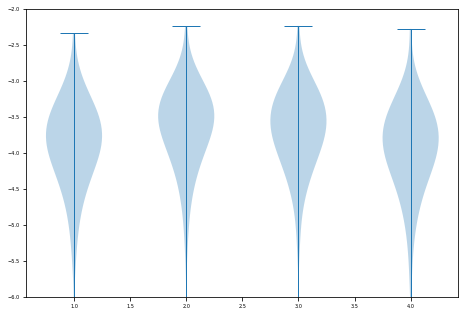

In [141]:

log10_condition_cluster_time_prop_ecdf = np.log10(condition_cluster_time_prop_ecdf)
gene_index = 3

## combine these different collections into a list
data_to_plot = [log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,0,gene_index,:],
               log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,1,gene_index,:],
               log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,2,gene_index,:],
               log10_condition_cluster_time_prop_ecdf[condition_index,cluster_index,3,gene_index,:]]

# Create a figure instance
fig = plt.figure()

# Create an axes instance
ax = fig.add_axes([0,0,1,1])

# Create the boxplot
bp = ax.violinplot(data_to_plot)
ax.set_ylim((-6,-2))



In [92]:
gene_index = 0
gene = adata.var_names[gene_index]
cluster_index = 0
cluster = clusters[cluster_index]
time_index = 0
time = times[time_index]


# # init condition_cluster_time_prop_ecdf: [num_conditions, num_clusters x num_times x num_genes x 101]
# condition_cluster_time_prop_ecdf = np.zeros((len(descriptions), len(clusters), len(times), adata.shape[1], 101))



plt.clf()
plt.scatter(times,)



# condition_index = 0
# condition = descriptions[condition_index]



In [64]:
quantiles = torch.arange(0,1.01,0.01)
quantiles


tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
        0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
        0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
        0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
        0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
        0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
        0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
        0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
        0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
        0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
        0.9900, 1.0000])

In [60]:
torch.flatten(samples, start_dim=0, end_dim=1).shape




torch.Size([91100, 5])

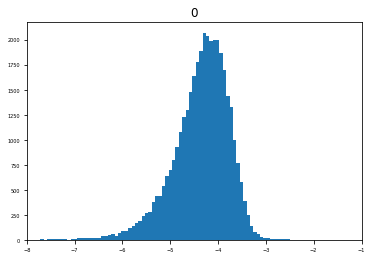

In [51]:
plt.clf()
plt.hist(np.log10(samples[:,:,3].flatten().detach().numpy()),bins=np.linspace(-8,-1,100))
plt.xlim((-8,-1))
plt.title(0)
plt.show()


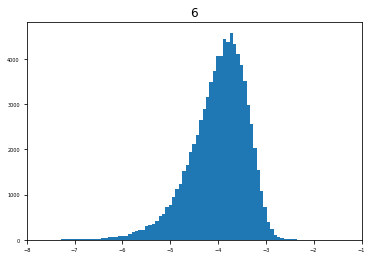

In [53]:
plt.clf()
plt.hist(np.log10(samples[:,:,3].flatten().detach().numpy()),bins=np.linspace(-8,-1,100))
plt.xlim((-8,-1))
plt.title(6)
plt.show()


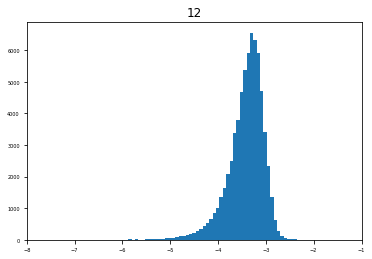

In [56]:
plt.clf()
plt.hist(np.log10(samples[:,:,3].flatten().detach().numpy()),bins=np.linspace(-8,-1,100))
plt.xlim((-8,-1))
plt.title(12)
plt.show()


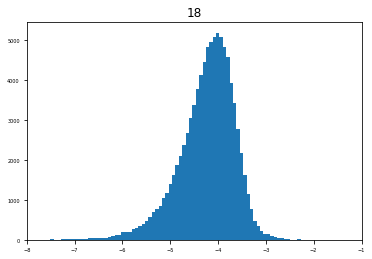

In [58]:
plt.clf()
plt.hist(np.log10(samples[:,:,3].flatten().detach().numpy()),bins=np.linspace(-8,-1,100))
plt.xlim((-8,-1))
plt.title(18)
plt.show()


In [ ]:
plt.clf()
plt.hist(np.log10(samples[:,:,3].flatten().detach().numpy()),bins=np.linspace(-8,-1,100))
plt.xlim((-8,-1))
plt.title(12)
plt.show()


In [25]:
# --- FOR EACH CELL AND GENE, SAMPLE 

cluster_condition_time_adata = cluster_condition_adata[cluster_condition_adata.obs['zt'] == time]


cluster_condition_time_adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 3703 × 5
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [ ]:

# 	import seaborn as sns

# 	fig, ax = plt.subplots(figsize = (args.x_size,args.y_size))
# 	for method,method_ecdf_df in zip(method_names,method_ecdf_df_list):
# 		method_name_cleaned = method.replace("_core_clock","")
# 		plt.plot(method_ecdf_df['e_cdf_hours'],method_ecdf_df['percentile'],label=method_name_cleaned,c=method_color_map[method_name_cleaned],alpha=0.5,linestyle=method_linestyle_map[method_name_cleaned])
# 	if args.t:
# 		plt.title(args.t)
# 	plt.ylabel("eCDF Percentile")
# 	plt.xlabel("eCDF Phase Error (Hours)")
# 	sns.despine()
# 	plt.legend(loc='lower right')
# 	plt.savefig(fileout,dpi=300,bbox_inches="tight")

